<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº4

#### Nicolás Galván

# Introducción

En el procesamiento digital de señales, la estimación espectral constituye una herramienta fundamental para caracterizar señales sinusoidales inmersas en ruido. En particular, la determinación precisa de parámetros como la amplitud y la frecuencia resulta esencial en aplicaciones de comunicaciones, instrumentación, audio y sistemas de medición.

En este trabajo práctico se estudia el comportamiento de distintos estimadores de amplitud y frecuencia aplicados a una señal senoidal contaminada con ruido blanco gaussiano aditivo (AWGN). La señal analizada se define como:

$$
x(n)=a_0 \cdot \sin(\Omega_1 n)+n_a(n)
$$

donde $a_0$ representa la amplitud de la senoidal, $\Omega_1$ su frecuencia angular discreta y $n_a(n)$ un proceso aleatorio gaussiano de media cero y varianza $\sigma^2$. Además, la frecuencia de la señal incorpora una perturbación aleatoria distribuida uniformemente, permitiendo analizar el desempeño de los estimadores frente a desalineamientos espectrales y efectos de *leakage*.

Para realizar la estimación de los parámetros se utiliza la Transformada Discreta de Fourier (DFT) aplicada sobre versiones ventaneadas de la señal. En particular, se comparan distintas funciones ventana: rectangular, Flat-top, Blackman-Harris y Gaussiana. Cada ventana modifica las propiedades espectrales de la señal, afectando tanto la resolución en frecuencia como el nivel de lóbulos laterales, lo que impacta directamente sobre el sesgo y la varianza de los estimadores.

El estimador de amplitud se obtiene a partir del módulo de la DFT evaluada en la frecuencia de interés, mientras que el estimador de frecuencia se calcula localizando el índice correspondiente al máximo valor espectral. Para evaluar estadísticamente el desempeño de cada método, se realizan múltiples realizaciones de la señal bajo distintos niveles de relación señal a ruido (SNR).

Finalmente, para cada ventana y condición de SNR, se analizan experimentalmente el sesgo y la varianza de los estimadores, permitiendo comparar la capacidad de cada ventana para estimar correctamente los parámetros de la señal en presencia de ruido y dispersión frecuencial.

# Ejercicio Nº1

# a)

### SNR de 3

Llamo a las librerías a utilizar.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Defino mis variables a implementar.

In [63]:
N = 1000
fs = N
realizaciones = 200
snr_db = 3
a_0 = np.sqrt(2)
omega_0 = fs / 4
df = fs / N

Genero mi vector frecuencia aleatoria con distribucion uniforme entre -2 y 2.

In [64]:
fr = np.random.uniform(-2, 2, realizaciones)

Convierte el vector en matriz fila (1 x 200) para facilitar operaciones matriciales.

In [65]:
fr = np.reshape(fr, (1, realizaciones))

Defino mi frecuencia central y se le agrega una pequeña variación aleatoria.

In [66]:
omega_1 = omega_0 + fr * df
f_1 = omega_1

Genero mi vector tiempo y lo convierto el vector tiempo en una columna (1000 x 1).

In [67]:
tt = np.arange(N).reshape(N, 1) / fs

Genero mis senoidales.

In [68]:
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

Cálculo la potencia teórica de una senoide.

In [69]:
potencia_senal = a_0**2 / 2

Cálculo el desvío estándar.

In [70]:
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

Genero mi ruido gaussiano.

In [71]:
ruido = np.random.normal(0, sigma, (N, realizaciones))

Genero mi señal final = senoide + ruido

In [72]:
x_1 = s_1 + ruido

Creo mi ventana rectangular

In [73]:
w = np.ones(N)

In [74]:
ganancia_w = np.sum(w)

La convierto en una columna.

In [75]:
w = w.reshape(N, 1)

Aplico la ventana a la señal.

In [76]:
xv = x_1 * w

Cálculo su FFT.

In [77]:
XXun = np.fft.fft(xv, axis=0)

Obtengo el módulo del espectro y me quedo con la mitad positiva del espectro.

In [78]:
XXunabs = np.abs(XXun[:N//2 + 1])

Implemento mi estimador de amplitud.

In [79]:
k_max = np.argmax(XXunabs, axis=0)
estimador_1_rect = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

Cálculo el sesgo.

In [80]:
sesgo_a    = np.mean(estimador_1_rect) - a_0

Cálculo  la varianza.

In [81]:
varianza_a = np.var(estimador_1_rect, ddof=1)

Imprimo los valores:

In [82]:
print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 1.2221096640851876
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.19210389828790753
Varianza    a   = 0.0264237649117694


Implemento mi estimador de frecuencia.

In [83]:
estimador_2_rect = k_max.astype(float)

Cálculo el sesgo.

In [84]:
sesgo_f    = np.mean(estimador_2_rect) - omega_0

Cálculo  la varianza.

In [85]:
varianza_f = np.var(estimador_2_rect, ddof=1)

Imprimo los valores:

In [86]:
print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 250.055
Valor real omega_0  = 250.0
Sesgo      w    = 0.05500000000000682
Varianza    w   = 1.5899246231155781



En todos estos bloques se repite exactamente el mismo procedimiento:

- Crear ventana.
- Aplicarla.
- Calcular FFT.
- Implementar el estimador de amplitud.
- Implementar el estimador de frecuencia.
- Calcular:
    - media
    - sesgo
    - varianza.

Lo único que se cambia es la ventana a utilizar.

In [87]:
# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_gauss = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_gauss) - a_0
varianza_a = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_gauss = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_gauss) - omega_0
varianza_f = np.var(estimador_2_gauss, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 1.3804513158286422
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.03376224654445292
Varianza    a   = 0.003146811336302904

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 250.055
Valor real omega_0  = 250.0
Sesgo      w    = 0.05500000000000682
Varianza    w   = 1.6100251256281408



In [88]:
# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])


# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_bh = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_bh) - a_0
varianza_a = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------


estimador_2_bh = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_bh) - omega_0
varianza_f = np.var(estimador_2_bh, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 1.371510469488322
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.04270309288477314
Varianza    a   = 0.0034046180630164296

Estimador de frecuencia — Ventana: Blackman-Harris
--------------------------------
Media estimada w = 250.055
Valor real omega_0  = 250.0
Sesgo      w    = 0.05500000000000682
Varianza    w   = 1.6100251256281408



In [89]:
# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_ft = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_ft) - a_0
varianza_a = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_ft = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_ft) - omega_0
varianza_f = np.var(estimador_2_ft, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

Estimador de amplitud — Ventana: Flat Top
--------------------------------
Media estimada a = 1.4245454373744544
Valor real a0  = 1.4142135623730951
Sesgo    a      = 0.010331875001359236
Varianza    a   = 0.0033839483378356352

Estimador de frecuencia — Ventana: Flat Top
--------------------------------
Media estimada w = 250.07
Valor real omega_0  = 250.0
Sesgo      w    = 0.06999999999999318
Varianza    w   = 1.5528643216080404



Se grafica los correspondientes histogramas de estimacion de frecuencia y de amplitud de cada ventana. Cabe aclarar que los histogramas de estimacion de frecuencia se encuentran todos juntos en un mismo grafico, asi como los histogramas de estimacion de amplitud.

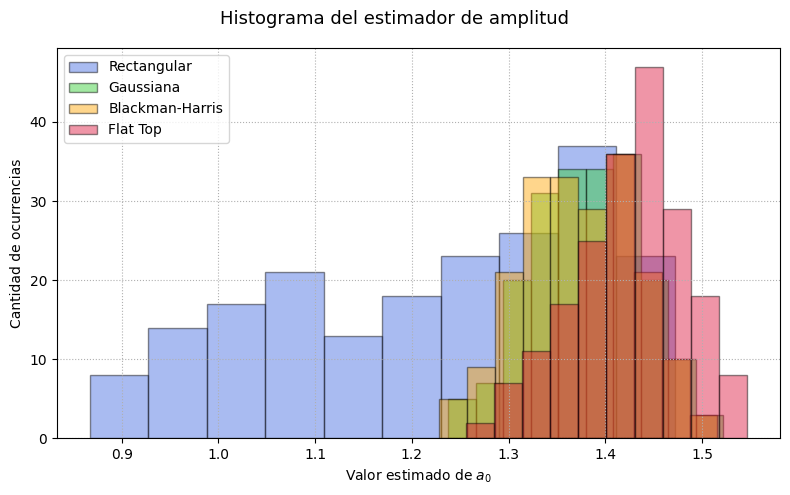

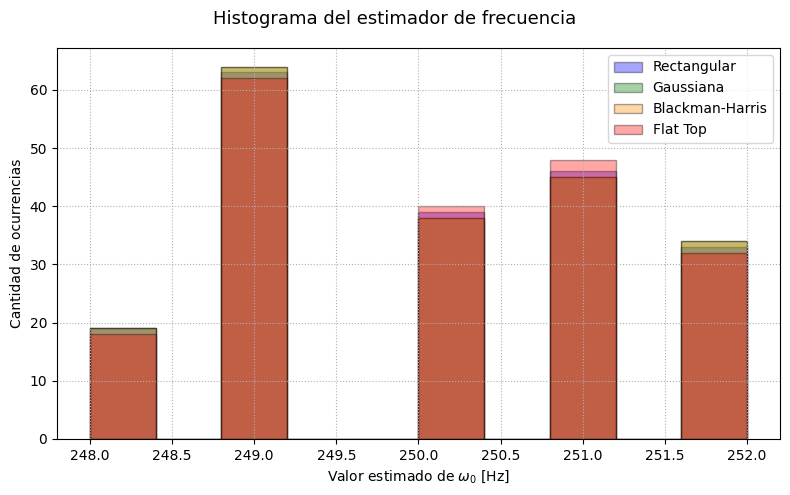

In [90]:
fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5))

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect,  bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue',      edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss,  bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green',     edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh,  bins=10, color='orange',     edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='darkorange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft,  bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red',     edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $\omega_0$ [Hz]')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()
plt.show()

# b)

### SNR de 10

Se realizo el mismo procedimiento mencionado en el a pero para un SNR de 10

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 1.231404667635905
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.1828088947371902
Varianza    a   = 0.024991712038731167
Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 249.995
Valor real omega_0  = 250.0
Sesgo      w    = -0.0049999999999954525
Varianza    w   = 1.401984924623116

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 1.3800633585873012
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.03415020378579392
Varianza    a   = 0.0014582517759452738

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 249.985
Valor real omega_0  = 250.0
Sesgo      w    = -0.014999999999986358
Varianza    w   = 1.4118341708542717

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 1.371796432081736

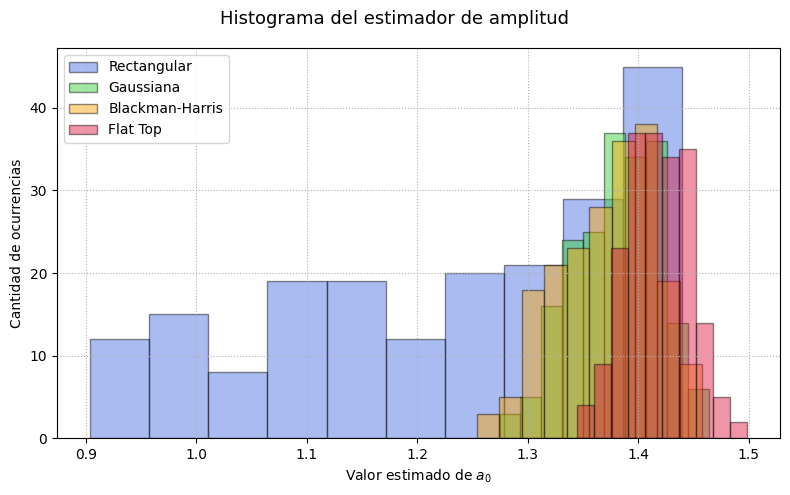

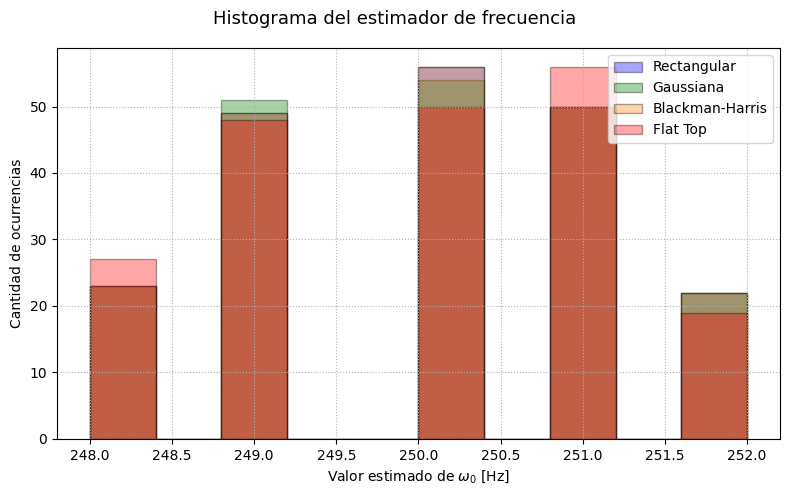

In [91]:
# Parámetros
N = 1000
fs = N
realizaciones = 200
snr_db = 10
a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

# Variable aleatoria fr ~ U(-2, 2)
fr = np.random.uniform(-2, 2, realizaciones)
# La paso a matriz fila: 1 x realizaciones
fr = np.reshape(fr, (1, realizaciones))

# Frecuencia angular discreta
omega_1 = omega_0 + fr * df

# Conversión a Hz
f_1 = omega_1

# Vector tiempo
tt = np.arange(N).reshape(N, 1) / fs

# Generación de senoidales
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

# Potencia de la señal
potencia_senal = a_0**2 / 2

# Desvío estándar del ruido
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

# Ruido independiente para cada muestra y cada realización
ruido = np.random.normal(0, sigma, (N, realizaciones))

# Señal con ruido
x_1 = s_1 + ruido

# =============================================================================
# VENTANA RECTANGULAR
# =============================================================================

w = np.ones(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)

estimador_1_rect = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_rect) - a_0
varianza_a = np.var(estimador_1_rect, ddof=1)

print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

estimador_2_rect = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_rect) - omega_0
varianza_f = np.var(estimador_2_rect, ddof=1)

print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()

# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)
estimador_1_gauss = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_gauss) - a_0
varianza_a = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_gauss = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_gauss) - omega_0
varianza_f = np.var(estimador_2_gauss, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])


# ---------------- AMPLITUD ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_1_bh = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_bh) - a_0
varianza_a = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_bh = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_bh) - omega_0
varianza_f = np.var(estimador_2_bh, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
ganancia_w = np.sum(w)
w = w.reshape(N, 1)

xv = x_1 * w
XXun = np.fft.fft(xv, axis=0)
XXunabs = np.abs(XXun[:N//2 + 1])

# ---------------- AMPLITUD ----------------
k_max = np.argmax(XXunabs, axis=0)
estimador_1_ft = 2 * np.abs(XXun[k_max, np.arange(realizaciones)]) / ganancia_w

sesgo_a    = np.mean(estimador_1_ft) - a_0
varianza_a = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgo_a)
print('Varianza    a   =', varianza_a)

# ---------------- FRECUENCIA ----------------

k_max = np.argmax(XXunabs, axis=0)
estimador_2_ft = k_max.astype(float)

sesgo_f    = np.mean(estimador_2_ft) - omega_0
varianza_f = np.var(estimador_2_ft, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgo_f)
print('Varianza    w   =', varianza_f)
print()
# =============================================================================
# GRAFICO FINAL
# =============================================================================

fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5))

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect,  bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue',      edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss,  bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green',     edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh,  bins=10, color='orange',     edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='darkorange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft,  bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red',     edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $\omega_0$ [Hz]')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()
plt.show()

# Resultados — SNR = 3 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.1921     | 0.0264         |
| Gaussiana        | -0.0338     | 0.0031         |
| Blackman-Harris  | -0.0427     | 0.0034         |
| Flat-top         | 0.0103      | 0.0034         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | 0.0550           | 1.5899              |
| Gaussiana        | 0.0550           | 1.6100              |
| Blackman-Harris  | 0.0550           | 1.6100              |
| Flat-top         | 0.0700           | 1.5529              |

---

# Resultados — SNR = 10 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.1828     | 0.0250         |
| Gaussiana        | -0.0342     | 0.0015         |
| Blackman-Harris  | -0.0424     | 0.0019         |
| Flat-top         | 0.0040      | 0.0008         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | -0.0050          | 1.4020              |
| Gaussiana        | -0.0150          | 1.4118              |
| Blackman-Harris  | -0.0050          | 1.4020              |
| Flat-top         | -0.0400          | 1.4456              |

# Análisis de Resultados

Los resultados obtenidos permiten evaluar el efecto de distintas ventanas espectrales sobre la estimación de amplitud y frecuencia de una señal senoidal contaminada con ruido blanco gaussiano. Para ello se analizaron 200 realizaciones independientes de una señal cuya frecuencia fue perturbada aleatoriamente alrededor de una frecuencia nominal de 250 Hz.

En cada realización la frecuencia se generó como

$$
f_1=f_0+f_r\Delta f
$$

donde $f_r\sim U(-2,2)$, por lo que la frecuencia verdadera varía aleatoriamente dentro de un intervalo de aproximadamente ±2 bins de la DFT.

La estimación se realizó localizando el máximo espectral de la FFT de la señal previamente ventaneada.

---

# Estimación de amplitud

Las diferencias más importantes entre ventanas aparecen en la estimación de amplitud.

La ventana rectangular presenta sistemáticamente el mayor sesgo negativo y la mayor varianza. Para SNR = 3 dB se obtiene un sesgo de aproximadamente -0.19 y una varianza cercana a 0.026, mientras que para SNR = 10 dB los valores permanecen prácticamente iguales.

Este comportamiento se debe a que la frecuencia de la señal rara vez coincide exactamente con un bin de la DFT. Como consecuencia, la energía de la senoidal se distribuye entre varios bins espectrales produciendo leakage espectral. Debido a que el estimador toma únicamente el valor máximo de la FFT, la amplitud resulta subestimada.

La ventana rectangular posee el lóbulo principal más angosto, pero también los lóbulos laterales más elevados. Esto provoca una fuerte sensibilidad al leakage generado por el desalineamiento frecuencial y explica la gran dispersión observada en los histogramas.

Las ventanas Gaussiana y Blackman-Harris mejoran significativamente el desempeño. Ambas reducen el sesgo a valores cercanos a -0.04 y disminuyen la varianza aproximadamente un orden de magnitud respecto de la ventana rectangular.

La ventana Flat-top es la que presenta el mejor comportamiento global. En ambos niveles de SNR el sesgo es prácticamente nulo:

- SNR = 3 dB: $s_a = 0.0103$
- SNR = 10 dB: $s_a = 0.0040$

Además, presenta una de las menores dispersiones estadísticas. Para SNR = 10 dB alcanza la menor varianza de todas las ventanas analizadas ($v_a \approx 0.0008$).

Este resultado coincide con el objetivo de diseño de la ventana Flat-top. Su espectro fue optimizado para realizar mediciones precisas de amplitud, minimizando la dependencia del valor estimado respecto de la posición exacta de la frecuencia dentro del bin.

Los histogramas permiten visualizar claramente este comportamiento: mientras la ventana rectangular presenta una distribución ancha y desplazada hacia valores menores que la amplitud real, la ventana Flat-top produce una distribución mucho más concentrada alrededor del valor verdadero.

---

# Estimación de frecuencia

En la estimación de frecuencia se observa un comportamiento diferente.

Los sesgos obtenidos son muy pequeños para todas las ventanas y las diferencias entre ellas resultan prácticamente despreciables.

Para SNR = 3 dB los sesgos se encuentran entre aproximadamente 0.055 Hz y 0.070 Hz, mientras que para SNR = 10 dB se ubican entre -0.040 Hz y -0.005 Hz.

Asimismo, las varianzas se mantienen alrededor de 1.4–1.6 Hz² independientemente del tipo de ventana utilizado.

A primera vista podría parecer que todas las ventanas poseen un desempeño similar para estimar frecuencia. Sin embargo, el análisis del código muestra que la principal fuente de dispersión no es el ruido ni el ventaneo, sino la propia generación aleatoria de la frecuencia de cada realización.

En efecto, la frecuencia verdadera varía entre realizaciones debido a la variable aleatoria $f_r$. Como el estimador consiste simplemente en seleccionar el bin de máxima energía, las diferencias observadas reflejan principalmente la distribución aleatoria de frecuencias presentes en el experimento.

Por este motivo las varianzas obtenidas son similares para todas las ventanas. El ventaneo modifica la forma del espectro, pero no altera significativamente el bin dominante detectado por el algoritmo.

Los histogramas de frecuencia confirman esta interpretación. Las estimaciones se concentran en unos pocos valores discretos cercanos a la frecuencia nominal (248 Hz, 249 Hz, 250 Hz, 251 Hz y 252 Hz), reflejando directamente la cuantización frecuencial de la DFT y la distribución uniforme utilizada para generar las frecuencias reales.

Por lo tanto, en este experimento la precisión de la estimación de frecuencia está limitada principalmente por la resolución espectral de la FFT y por la variabilidad introducida deliberadamente mediante $f_r$, más que por el tipo de ventana utilizado.

---

# Influencia del SNR

Al aumentar la relación señal-ruido de 3 dB a 10 dB se observa una mejora moderada en la estimación de amplitud para las ventanas suavizadas.

Las ventanas Gaussiana, Blackman-Harris y Flat-top reducen significativamente sus varianzas al disminuir el ruido:

- Gaussiana: de 0.0031 a 0.0015.
- Blackman-Harris: de 0.0034 a 0.0019.
- Flat-top: de 0.0034 a 0.0008.

En cambio, la ventana rectangular prácticamente no mejora, manteniendo una varianza cercana a 0.025. Esto indica que su error está dominado por el leakage espectral asociado al desalineamiento frecuencial y no por el ruido aditivo.

Para la estimación de frecuencia las diferencias entre ambos niveles de SNR son relativamente pequeñas. Las varianzas permanecen del mismo orden y continúan dominadas por la dispersión introducida por la frecuencia aleatoria de cada realización y por la resolución discreta de la FFT.

---

# Relación con la teoría de análisis espectral

La teoría del análisis espectral establece que el ventaneo modifica el espectro observado mediante cambios en el ancho del lóbulo principal y en el nivel de los lóbulos laterales.

La ventana rectangular posee la mejor resolución espectral teórica, pero presenta un rechazo pobre del leakage debido a sus elevados lóbulos laterales.

Las ventanas Gaussiana y Blackman-Harris reducen significativamente los lóbulos laterales, logrando una mejor estabilidad en la estimación de amplitud.

La ventana Flat-top lleva este compromiso aún más lejos. Aunque posee un lóbulo principal considerablemente más ancho, proporciona una medición de amplitud mucho más precisa, característica que queda claramente reflejada en los resultados experimentales.

---

# Conclusiones

Los resultados muestran que el efecto del ventaneo es particularmente importante en la estimación de amplitud.

La ventana Flat-top presenta el mejor desempeño global, obteniendo un sesgo muy cercano a cero y una baja varianza tanto para SNR = 3 dB como para SNR = 10 dB. Las ventanas Gaussiana y Blackman-Harris también ofrecen resultados satisfactorios y significativamente mejores que la ventana rectangular.

La ventana rectangular exhibe la mayor sensibilidad al leakage espectral y, por lo tanto, los mayores errores de amplitud.

En la estimación de frecuencia las diferencias entre ventanas son reducidas. La dispersión observada está dominada por la variación aleatoria de frecuencia introducida en la simulación y por la resolución discreta de la FFT, más que por el tipo de ventana empleado.

En consecuencia, si el objetivo principal es obtener mediciones precisas de amplitud, la ventana Flat-top constituye la mejor elección dentro de las analizadas. Para la estimación de frecuencia, en cambio, ninguna ventana presenta una ventaja significativa bajo el esquema de estimación utilizado.

# Autoevaluación del aprendizaje

La realización de este trabajo práctico permitió profundizar conceptos fundamentales de análisis espectral y procesamiento digital de señales. En particular, se logró comprender de manera práctica cómo el uso de distintas ventanas modifica el espectro obtenido mediante la Transformada Discreta de Fourier (DFT) y cómo estos efectos impactan sobre la estimación de amplitud y frecuencia de una señal senoidal inmersa en ruido.

Uno de los aspectos más importantes observados fue el fenómeno de *spectral leakage*. Se verificó experimentalmente que, cuando la frecuencia de la señal no coincide exactamente con un bin de la FFT, la energía espectral se distribuye entre varios bins, provocando una subestimación de la amplitud cuando se utiliza como estimador el máximo valor de la magnitud espectral. Este efecto se manifestó especialmente en la ventana rectangular, que presentó los mayores sesgos y varianzas en la estimación de amplitud.

Asimismo, el trabajo permitió analizar el compromiso existente entre resolución espectral y atenuación de lóbulos laterales. Se observó que la ventana rectangular posee la mejor resolución teórica en frecuencia, pero también una elevada sensibilidad al leakage. Por otro lado, las ventanas Gaussiana y Blackman-Harris reducen significativamente la dispersión de las estimaciones de amplitud gracias a una mejor supresión de lóbulos laterales.

Particularmente, los resultados mostraron que la ventana Flat-top fue la que ofreció la mejor precisión en la estimación de amplitud, obteniendo sesgos muy cercanos a cero y las menores varianzas entre todas las ventanas analizadas. Esto permitió comprobar experimentalmente el propósito para el cual fue diseñada esta ventana: realizar mediciones de amplitud con mínima dependencia de la ubicación exacta de la frecuencia dentro de un bin espectral.

Otro aspecto relevante fue el análisis estadístico de los estimadores mediante el cálculo de sesgo y varianza a partir de múltiples realizaciones de una señal con frecuencia aleatoria. Esto permitió relacionar conceptos teóricos de estimación con resultados experimentales concretos y observar cómo el ventaneo y la relación señal-ruido afectan el desempeño de los estimadores.

Además, se pudo comprobar que, bajo el esquema de estimación utilizado, las diferencias entre ventanas para la estimación de frecuencia fueron poco significativas. La dispersión observada estuvo dominada principalmente por la variación aleatoria introducida en la frecuencia de la señal y por la resolución discreta de la FFT, más que por el tipo de ventana empleado.

Desde el punto de vista computacional, el trabajo permitió adquirir mayor experiencia en el uso de Python y bibliotecas especializadas como NumPy, SciPy y Matplotlib para la generación de señales aleatorias, aplicación de ventanas, cálculo de FFT, análisis estadístico de resultados y representación gráfica mediante histogramas.

En conclusión, el trabajo contribuyó tanto a consolidar conceptos teóricos relacionados con el análisis espectral y el diseño de ventanas como a desarrollar herramientas prácticas para la simulación, procesamiento y análisis estadístico de señales digitales. Además, permitió interpretar críticamente los resultados obtenidos y relacionarlos con los fundamentos teóricos estudiados en la materia.